In [1]:
# Basic tools for the working-point checks

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from hp_core import (
    lyapunov_spectrum_blocks,
    spectrum_statistics,
    z_maxima
)


# Output folders

Path("data").mkdir(
    exist_ok=True
)

Path("figures").mkdir(
    exist_ok=True
)

In [2]:
# Fixed Hastings-Powell parameters

a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d2 = 0.01


# Working points

d1_040 = 0.40
d1_038 = 0.38


# Parameter arrays used by hp_core

parameters_040 = np.array([
    a1,
    a2,
    b1,
    b2,
    d1_040,
    d2
])

parameters_038 = np.array([
    a1,
    a2,
    b1,
    b2,
    d1_038,
    d2
])


# Reference initial condition

reference_state = np.array([
    1.0,
    1.0,
    1.0
])


# Main and convergence time steps

dt_main = 0.01
dt_half = 0.005

In [3]:
# Integration times

transient_time = 20000.0
alignment_time = 5000.0
average_time = 200000.0

renormalization_time = 1.0
block_time = 2500.0


# z-maxima settings

record_time = 20000.0
max_peaks = 500

In [4]:
# Initial conditions for the working-point checks

rng = np.random.default_rng(
    12345
)

random_initial_states = rng.uniform(
    0.1,
    2.0,
    size=(15, 3)
)

initial_states = np.vstack([
    reference_state,
    random_initial_states
])


print(
    "Number of initial conditions:",
    len(initial_states)
)

print(
    initial_states
)

Number of initial conditions: 16
[[1.         1.         1.        ]
 [0.53193844 0.70184085 1.61499437]
 [1.38488387 0.84310815 0.73234646]
 [1.23678663 0.45479495 1.37823648]
 [1.88942544 0.57166686 1.90287419]
 [1.36775116 0.28220608 0.93949537]
 [1.78431185 1.42516165 0.72029844]
 [1.49446351 0.51825642 0.25502968]
 [0.40380164 0.74619035 0.98386699]
 [0.60619995 1.64997517 0.46725934]
 [0.34599124 0.27416303 1.23727923]
 [1.72400962 1.24308036 1.87077789]
 [1.47708459 1.7350475  1.86574182]
 [1.13775342 1.88157862 1.04047709]
 [0.62016905 0.95837954 1.36357395]
 [0.72869277 1.81656261 0.58844093]]


In [5]:
# Storage for d1 = 0.40

checks_040 = []
blocks_040 = []
maxima_040 = []

In [6]:
# Full working-point check at d1 = 0.40

for i, state0 in enumerate(initial_states):

    # Long Lyapunov spectrum
    block_exponents, final_state, mean_trace = lyapunov_spectrum_blocks(
        parameters_040,
        state0,
        dt_main,
        transient_time,
        alignment_time,
        average_time,
        renormalization_time,
        block_time
    )


    (
        spectrum,
        errors,
        first_half,
        second_half,
        drift,
        stationary
    ) = spectrum_statistics(
        block_exponents
    )


    # Trace consistency
    spectrum_sum = np.sum(
        spectrum
    )

    trace_difference = abs(
        spectrum_sum - mean_trace
    )


    # Maxima of z
    maxima, _ = z_maxima(
        parameters_040,
        state0,
        dt_main,
        transient_time,
        record_time,
        max_peaks
    )


    distinct_maxima = len(
        np.unique(
            np.round(
                maxima,
                3
            )
        )
    )

    mean_zmax = np.mean(
        maxima
    )

    std_zmax = np.std(
        maxima
    )


    # Save the complete summary
    checks_040.append([
        i,
        state0[0],
        state0[1],
        state0[2],

        spectrum[0],
        errors[0],
        spectrum[1],
        errors[1],
        spectrum[2],
        errors[2],

        first_half[0],
        first_half[1],
        first_half[2],

        second_half[0],
        second_half[1],
        second_half[2],

        drift[0],
        drift[1],
        drift[2],

        stationary[0],
        stationary[1],
        stationary[2],

        spectrum_sum,
        mean_trace,
        trace_difference,

        distinct_maxima,
        mean_zmax,
        std_zmax,

        final_state[0],
        final_state[1],
        final_state[2]
    ])


    # Save every Lyapunov block
    for block_index, block_values in enumerate(
        block_exponents,
        start=1
    ):

        blocks_040.append([
            i,
            block_index,
            block_values[0],
            block_values[1],
            block_values[2]
        ])


    # Save the maxima in temporal order
    for peak_index, z_peak in enumerate(
        maxima,
        start=1
    ):

        maxima_040.append([
            i,
            peak_index,
            z_peak
        ])


    print(
        f"[{i + 1:02d}/{len(initial_states)}] "
        f"IC = {i:02d}   "
        f"lambda1 = {spectrum[0]:.6f}   "
        f"lambda2 = {spectrum[1]:.6f}   "
        f"stationary = {stationary[0]}   "
        f"trace diff = {trace_difference:.2e}   "
        f"distinct maxima = {distinct_maxima}",
        flush=True
    )

[01/16] IC = 00   lambda1 = 0.007039   lambda2 = -0.000007   stationary = True   trace diff = 1.01e-08   distinct maxima = 315
[02/16] IC = 01   lambda1 = 0.006812   lambda2 = -0.000011   stationary = True   trace diff = 2.06e-08   distinct maxima = 323
[03/16] IC = 02   lambda1 = 0.006940   lambda2 = -0.000007   stationary = True   trace diff = 2.15e-09   distinct maxima = 339
[04/16] IC = 03   lambda1 = 0.006777   lambda2 = 0.000006   stationary = True   trace diff = 3.95e-09   distinct maxima = 343
[05/16] IC = 04   lambda1 = 0.006948   lambda2 = 0.000011   stationary = True   trace diff = 1.16e-08   distinct maxima = 330
[06/16] IC = 05   lambda1 = 0.006986   lambda2 = 0.000007   stationary = True   trace diff = 1.03e-08   distinct maxima = 338
[07/16] IC = 06   lambda1 = 0.006806   lambda2 = 0.000006   stationary = False   trace diff = 1.37e-09   distinct maxima = 317
[08/16] IC = 07   lambda1 = 0.006817   lambda2 = -0.000003   stationary = False   trace diff = 5.66e-10   distinct

In [7]:
# Convert d1 = 0.40 results to arrays

checks_040 = np.array(
    checks_040,
    dtype=float
)

blocks_040 = np.array(
    blocks_040,
    dtype=float
)

maxima_040 = np.array(
    maxima_040,
    dtype=float
)


print(
    "Checks:",
    checks_040.shape
)

print(
    "Blocks:",
    blocks_040.shape
)

print(
    "Maxima:",
    maxima_040.shape
)

Checks: (16, 31)
Blocks: (1280, 5)
Maxima: (6770, 3)


In [8]:
# Compact summary for d1 = 0.40

print(
    "IC   "
    "lambda1      error1      "
    "lambda2      error2      "
    "lambda3      error3      "
    "stat1  stat2  stat3  "
    "trace_diff    "
    "distinct"
)


for row in checks_040:

    print(
        f"{int(row[0]):02d}   "
        f"{row[4]: .6f}   "
        f"{row[5]:.6f}   "
        f"{row[6]: .6f}   "
        f"{row[7]:.6f}   "
        f"{row[8]: .6f}   "
        f"{row[9]:.6f}   "
        f"{int(row[19]):1d}      "
        f"{int(row[20]):1d}      "
        f"{int(row[21]):1d}      "
        f"{row[24]:.2e}      "
        f"{int(row[25]):3d}"
    )

IC   lambda1      error1      lambda2      error2      lambda3      error3      stat1  stat2  stat3  trace_diff    distinct
00    0.007039   0.000256   -0.000007   0.000194   -0.464095   0.000744   1      1      1      1.01e-08      315
01    0.006812   0.000220   -0.000011   0.000133   -0.463629   0.000831   1      1      1      2.06e-08      323
02    0.006940   0.000249   -0.000007   0.000148   -0.463771   0.000797   1      1      1      2.15e-09      339
03    0.006777   0.000268    0.000006   0.000136   -0.463873   0.000961   1      1      1      3.95e-09      343
04    0.006948   0.000235    0.000011   0.000136   -0.463539   0.000858   1      1      1      1.16e-08      330
05    0.006986   0.000178    0.000007   0.000155   -0.463830   0.000851   1      1      1      1.03e-08      338
06    0.006806   0.000219    0.000006   0.000145   -0.463599   0.000919   0      1      1      1.37e-09      317
07    0.006817   0.000224   -0.000003   0.000176   -0.463436   0.000872   0      1   

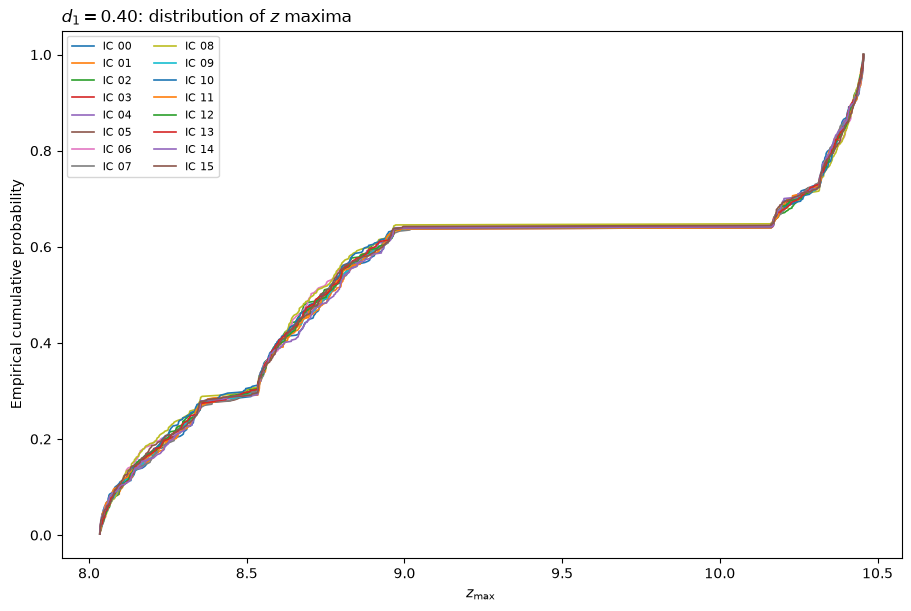

In [9]:
# Distribution of z maxima at d1 = 0.40

fig, ax = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True
)


for i in range(len(initial_states)):

    peaks = maxima_040[
        maxima_040[:, 0] == i,
        2
    ]

    peaks = np.sort(
        peaks
    )

    cumulative = np.arange(
        1,
        len(peaks) + 1
    ) / len(peaks)

    ax.plot(
        peaks,
        cumulative,
        linewidth=1.2,
        label=f"IC {i:02d}"
    )


ax.set_xlabel(
    r"$z_{\max}$"
)

ax.set_ylabel(
    "Empirical cumulative probability"
)

ax.set_title(
    r"$d_1 = 0.40$: distribution of $z$ maxima",
    loc="left"
)

ax.legend(
    ncol=2,
    fontsize=8
)


fig.savefig(
    "figures/hp_d1_040_maxima_ecdf.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_d1_040_maxima_ecdf.pdf",
    bbox_inches="tight"
)

plt.show()

In [10]:
# Compare the z-maxima distributions at d1 = 0.40

reference_peaks_040 = maxima_040[
    maxima_040[:, 0] == 0,
    2
]

reference_peaks_040 = np.sort(
    reference_peaks_040
)


ecdf_distance_040 = np.zeros(
    len(initial_states)
)


print(
    "IC   mean_zmax   std_zmax   "
    "ECDF_distance"
)


for i in range(len(initial_states)):

    peaks = maxima_040[
        maxima_040[:, 0] == i,
        2
    ]

    peaks = np.sort(
        peaks
    )


    # Common grid for both distributions
    values = np.sort(
        np.concatenate([
            reference_peaks_040,
            peaks
        ])
    )


    reference_ecdf = np.searchsorted(
        reference_peaks_040,
        values,
        side="right"
    ) / len(reference_peaks_040)

    current_ecdf = np.searchsorted(
        peaks,
        values,
        side="right"
    ) / len(peaks)


    ecdf_distance_040[i] = np.max(
        np.abs(
            reference_ecdf
            - current_ecdf
        )
    )


    print(
        f"{i:02d}   "
        f"{np.mean(peaks):.6f}   "
        f"{np.std(peaks):.6f}   "
        f"{ecdf_distance_040[i]:.6f}"
    )

IC   mean_zmax   std_zmax   ECDF_distance
00   9.154745   0.930491   0.000000
01   9.150294   0.930694   0.027817
02   9.144957   0.936241   0.044917
03   9.151885   0.936727   0.029456
04   9.151750   0.932921   0.028183
05   9.151181   0.935127   0.033097
06   9.143784   0.939563   0.053197
07   9.155246   0.932030   0.029456
08   9.132133   0.942097   0.048713
09   9.151888   0.934089   0.021427
10   9.141963   0.940215   0.037825
11   9.153940   0.935061   0.021602
12   9.149575   0.935950   0.030175
13   9.147393   0.935080   0.031853
14   9.155372   0.929985   0.022459
15   9.144410   0.935534   0.030076


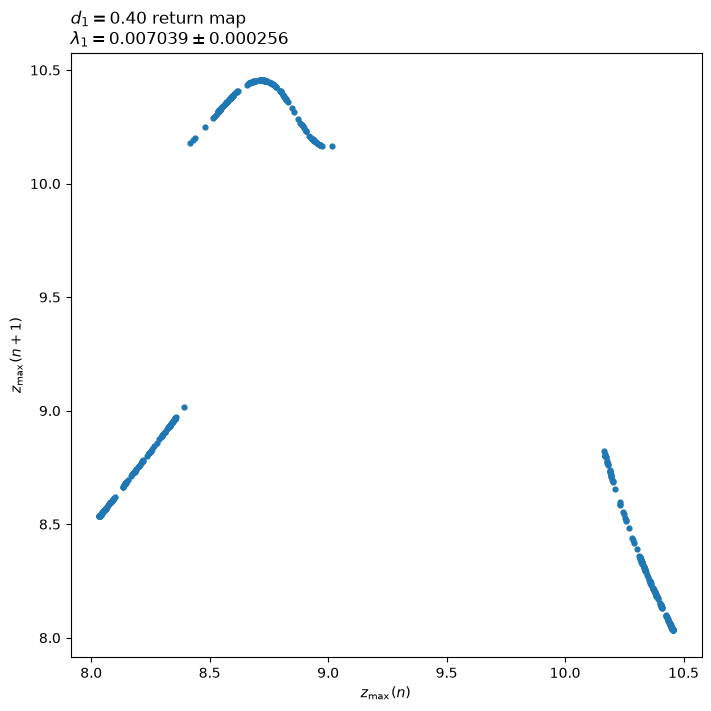

In [11]:
# Return map at d1 = 0.40

reference_maxima_040 = maxima_040[
    maxima_040[:, 0] == 0
]

reference_maxima_040 = reference_maxima_040[
    np.argsort(
        reference_maxima_040[:, 1]
    )
]

peaks_040 = reference_maxima_040[
    :,
    2
]


fig, ax = plt.subplots(
    figsize=(7, 7),
    constrained_layout=True
)


ax.scatter(
    peaks_040[:-1],
    peaks_040[1:],
    s=12
)


ax.set_xlabel(
    r"$z_{\max}(n)$"
)

ax.set_ylabel(
    r"$z_{\max}(n+1)$"
)

ax.set_title(
    (
        r"$d_1 = 0.40$ return map"
        "\n"
        rf"$\lambda_1 = {checks_040[0, 4]:.6f}"
        rf" \pm {checks_040[0, 5]:.6f}$"
    ),
    loc="left"
)


fig.savefig(
    "figures/hp_d1_040_return_map.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_d1_040_return_map.pdf",
    bbox_inches="tight"
)

plt.show()

In [12]:
# Time-step convergence check at d1 = 0.40

(
    block_exponents_dt_040,
    final_state_dt_040,
    mean_trace_dt_040
) = lyapunov_spectrum_blocks(
    parameters_040,
    reference_state,
    dt_half,
    transient_time,
    alignment_time,
    average_time,
    renormalization_time,
    block_time
)


(
    spectrum_dt_040,
    errors_dt_040,
    first_half_dt_040,
    second_half_dt_040,
    drift_dt_040,
    stationary_dt_040
) = spectrum_statistics(
    block_exponents_dt_040
)


spectrum_sum_dt_040 = np.sum(
    spectrum_dt_040
)

trace_difference_dt_040 = abs(
    spectrum_sum_dt_040
    - mean_trace_dt_040
)


print(
    "dt:",
    dt_half
)

print(
    "Spectrum:",
    spectrum_dt_040
)

print(
    "Errors:",
    errors_dt_040
)

print(
    "Drift:",
    drift_dt_040
)

print(
    "Stationary:",
    stationary_dt_040
)

print(
    "Trace difference:",
    trace_difference_dt_040
)

dt: 0.005
Spectrum: [ 6.77773391e-03  6.06766253e-06 -4.63773715e-01]
Errors: [0.00024264 0.00016623 0.00097296]
Drift: [3.16868570e-04 1.13764468e-05 6.18731485e-04]
Stationary: [False  True  True]
Trace difference: 3.2164262364631213e-09


In [13]:
# Compare dt = 0.01 and dt = 0.005 at d1 = 0.40

spectrum_main_040 = np.array([
    checks_040[0, 4],
    checks_040[0, 6],
    checks_040[0, 8]
])

errors_main_040 = np.array([
    checks_040[0, 5],
    checks_040[0, 7],
    checks_040[0, 9]
])


difference_dt_040 = np.abs(
    spectrum_main_040
    - spectrum_dt_040
)

combined_error_040 = (
    errors_main_040
    + errors_dt_040
)

consistent_dt_040 = (
    difference_dt_040
    <= combined_error_040
)


print(
    "Exponent   dt=0.01      dt=0.005     "
    "difference    combined_error    consistent"
)


for i in range(3):

    print(
        f"lambda{i + 1}    "
        f"{spectrum_main_040[i]: .6f}    "
        f"{spectrum_dt_040[i]: .6f}    "
        f"{difference_dt_040[i]:.6f}      "
        f"{combined_error_040[i]:.6f}          "
        f"{consistent_dt_040[i]}"
    )

Exponent   dt=0.01      dt=0.005     difference    combined_error    consistent
lambda1     0.007039     0.006778    0.000262      0.000499          True
lambda2    -0.000007     0.000006    0.000013      0.000360          True
lambda3    -0.464095    -0.463774    0.000321      0.001717          True


In [14]:
# Save all results for d1 = 0.40


# Add the ECDF distance to the main summary

checks_040_save = np.column_stack([
    checks_040,
    ecdf_distance_040
])


checks_header_040 = """Hastings-Powell working-point checks at d1 = 0.40

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.40
d2 = 0.01

Main integration:
dt = 0.01
transient_time = 20000
alignment_time = 5000
average_time = 200000
renormalization_time = 1
block_time = 2500

z-maxima:
record_time = 20000
max_peaks = 500

Initial conditions:
reference = [1.0, 1.0, 1.0]
15 random initial conditions
random interval = [0.1, 2.0]
random seed = 12345

Errors:
largest half-width among approximate 95% Student intervals
obtained with block groupings of 1, 2 and 4

Stationarity:
first-half and second-half Lyapunov means are compared
component by component
stationary = 1 when drift <= reported error

ECDF distance:
maximum absolute difference from the empirical distribution
of z maxima for the reference initial condition

columns:
IC,x0,y0,z0,
lambda1,error1,lambda2,error2,lambda3,error3,
first_half1,first_half2,first_half3,
second_half1,second_half2,second_half3,
drift1,drift2,drift3,
stationary1,stationary2,stationary3,
spectrum_sum,mean_trace,trace_difference,
distinct_maxima,mean_zmax,std_zmax,
final_x,final_y,final_z,
ecdf_distance
"""


np.savetxt(
    "data/hp_d1_040_checks.csv",
    checks_040_save,
    delimiter=",",
    header=checks_header_040,
    comments="# ",
    fmt="%.16e"
)


# Main dt = 0.01 blocks

main_blocks_040 = np.column_stack([
    np.full(
        len(blocks_040),
        dt_main
    ),
    blocks_040
])


# Reference-condition blocks for dt = 0.005

half_blocks_040 = np.column_stack([
    np.full(
        len(block_exponents_dt_040),
        dt_half
    ),
    np.zeros(
        len(block_exponents_dt_040)
    ),
    np.arange(
        1,
        len(block_exponents_dt_040) + 1
    ),
    block_exponents_dt_040
])


all_blocks_040 = np.vstack([
    main_blocks_040,
    half_blocks_040
])


blocks_header_040 = """Lyapunov blocks at d1 = 0.40

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.40
d2 = 0.01

Integration:
transient_time = 20000
alignment_time = 5000
average_time = 200000
renormalization_time = 1
block_time = 2500

dt = 0.01:
16 initial conditions

dt = 0.005:
reference initial condition only
IC = 0
reference = [1.0, 1.0, 1.0]

columns:
dt,IC,block,lambda1_block,lambda2_block,lambda3_block
"""


np.savetxt(
    "data/hp_d1_040_blocks.csv",
    all_blocks_040,
    delimiter=",",
    header=blocks_header_040,
    comments="# ",
    fmt="%.16e"
)


# Save z maxima in temporal order

maxima_header_040 = """Successive maxima of z at d1 = 0.40

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.40
d2 = 0.01

dt = 0.01
transient_time = 20000
record_time = 20000
max_peaks = 500

Initial conditions:
reference = [1.0, 1.0, 1.0]
15 random initial conditions
random interval = [0.1, 2.0]
random seed = 12345

columns:
IC,peak_index,z_max
"""


np.savetxt(
    "data/hp_d1_040_maxima.csv",
    maxima_040,
    delimiter=",",
    header=maxima_header_040,
    comments="# ",
    fmt="%.16e"
)


# Save the dt convergence comparison

dt_convergence_040 = np.column_stack([
    np.arange(
        1,
        4
    ),
    spectrum_main_040,
    errors_main_040,
    spectrum_dt_040,
    errors_dt_040,
    difference_dt_040,
    combined_error_040,
    consistent_dt_040.astype(float)
])


dt_header_040 = f"""Time-step convergence check at d1 = 0.40

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.40
d2 = 0.01

Initial condition:
[1.0, 1.0, 1.0]

Integration:
transient_time = 20000
alignment_time = 5000
average_time = 200000
renormalization_time = 1
block_time = 2500

main_dt = 0.01
half_dt = 0.005

main_trace_difference = {checks_040[0, 24]:.16e}
half_trace_difference = {trace_difference_dt_040:.16e}

Consistency criterion:
absolute difference <= error_dt_0.01 + error_dt_0.005

columns:
exponent,lambda_dt_0.01,error_dt_0.01,
lambda_dt_0.005,error_dt_0.005,
absolute_difference,combined_error,consistent
"""


np.savetxt(
    "data/hp_d1_040_dt_convergence.csv",
    dt_convergence_040,
    delimiter=",",
    header=dt_header_040,
    comments="# ",
    fmt="%.16e"
)


print(
    "Saved: data/hp_d1_040_checks.csv"
)

print(
    "Saved: data/hp_d1_040_blocks.csv"
)

print(
    "Saved: data/hp_d1_040_maxima.csv"
)

print(
    "Saved: data/hp_d1_040_dt_convergence.csv"
)

Saved: data/hp_d1_040_checks.csv
Saved: data/hp_d1_040_blocks.csv
Saved: data/hp_d1_040_maxima.csv
Saved: data/hp_d1_040_dt_convergence.csv


In [15]:
# Report stationarity flags at d1 = 0.40

error_columns = [5, 7, 9]
first_half_columns = [10, 11, 12]
second_half_columns = [13, 14, 15]
drift_columns = [16, 17, 18]
stationary_columns = [19, 20, 21]


print("Main integration: dt = 0.01")
print()


flagged_main_040 = []


for row in checks_040:

    ic_index = int(
        row[0]
    )

    for exponent_index in range(3):

        stationary_value = bool(
            row[
                stationary_columns[
                    exponent_index
                ]
            ]
        )

        if not stationary_value:

            error = row[
                error_columns[
                    exponent_index
                ]
            ]

            drift = row[
                drift_columns[
                    exponent_index
                ]
            ]

            ratio = (
                drift / error
                if error > 0.0
                else np.inf
            )


            flagged_main_040.append([
                ic_index,
                exponent_index + 1,
                row[
                    first_half_columns[
                        exponent_index
                    ]
                ],
                row[
                    second_half_columns[
                        exponent_index
                    ]
                ],
                drift,
                error,
                ratio
            ])


            print(
                f"IC {ic_index:02d}   "
                f"lambda{exponent_index + 1}   "
                f"first = "
                f"{row[first_half_columns[exponent_index]]:.6f}   "
                f"second = "
                f"{row[second_half_columns[exponent_index]]:.6f}   "
                f"drift = {drift:.6f}   "
                f"error = {error:.6f}   "
                f"drift/error = {ratio:.3f}"
            )


if len(flagged_main_040) == 0:

    print(
        "No stationarity flags."
    )


print()
print("Convergence integration: dt = 0.005")
print()


flagged_half_040 = []


for exponent_index in range(3):

    if not stationary_dt_040[
        exponent_index
    ]:

        error = errors_dt_040[
            exponent_index
        ]

        drift = drift_dt_040[
            exponent_index
        ]

        ratio = (
            drift / error
            if error > 0.0
            else np.inf
        )


        flagged_half_040.append([
            exponent_index + 1,
            first_half_dt_040[
                exponent_index
            ],
            second_half_dt_040[
                exponent_index
            ],
            drift,
            error,
            ratio
        ])


        print(
            f"lambda{exponent_index + 1}   "
            f"first = "
            f"{first_half_dt_040[exponent_index]:.6f}   "
            f"second = "
            f"{second_half_dt_040[exponent_index]:.6f}   "
            f"drift = {drift:.6f}   "
            f"error = {error:.6f}   "
            f"drift/error = {ratio:.3f}"
        )


if len(flagged_half_040) == 0:

    print(
        "No stationarity flags."
    )

Main integration: dt = 0.01

IC 06   lambda1   first = 0.006935   second = 0.006678   drift = 0.000258   error = 0.000219   drift/error = 1.173
IC 07   lambda1   first = 0.006950   second = 0.006685   drift = 0.000265   error = 0.000224   drift/error = 1.182
IC 10   lambda1   first = 0.007124   second = 0.006865   drift = 0.000259   error = 0.000223   drift/error = 1.159

Convergence integration: dt = 0.005

lambda1   first = 0.006619   second = 0.006936   drift = 0.000317   error = 0.000243   drift/error = 1.306


In [16]:
# Small fix: include stationarity details in the dt check

main_first_half_040 = np.array([
    checks_040[0, 10],
    checks_040[0, 11],
    checks_040[0, 12]
])

main_second_half_040 = np.array([
    checks_040[0, 13],
    checks_040[0, 14],
    checks_040[0, 15]
])

main_drift_040 = np.array([
    checks_040[0, 16],
    checks_040[0, 17],
    checks_040[0, 18]
])

main_stationary_040 = np.array([
    checks_040[0, 19],
    checks_040[0, 20],
    checks_040[0, 21]
])


dt_convergence_040 = np.column_stack([
    np.arange(1, 4),

    spectrum_main_040,
    errors_main_040,
    main_first_half_040,
    main_second_half_040,
    main_drift_040,
    main_stationary_040,

    spectrum_dt_040,
    errors_dt_040,
    first_half_dt_040,
    second_half_dt_040,
    drift_dt_040,
    stationary_dt_040.astype(float),

    difference_dt_040,
    combined_error_040,
    consistent_dt_040.astype(float)
])


dt_header_040 = f"""Time-step convergence check at d1 = 0.40

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.40
d2 = 0.01

Initial condition:
[1.0, 1.0, 1.0]

Integration:
transient_time = 20000
alignment_time = 5000
average_time = 200000
renormalization_time = 1
block_time = 2500

main_dt = 0.01
half_dt = 0.005

main_trace_difference = {checks_040[0, 24]:.16e}
half_trace_difference = {trace_difference_dt_040:.16e}

Stationarity criterion:
drift <= reported error

Time-step consistency criterion:
absolute difference <= error_dt_0.01 + error_dt_0.005

columns:
exponent,
lambda_dt_0.01,error_dt_0.01,
first_half_dt_0.01,second_half_dt_0.01,
drift_dt_0.01,stationary_dt_0.01,
lambda_dt_0.005,error_dt_0.005,
first_half_dt_0.005,second_half_dt_0.005,
drift_dt_0.005,stationary_dt_0.005,
absolute_difference,combined_error,consistent
"""


np.savetxt(
    "data/hp_d1_040_dt_convergence.csv",
    dt_convergence_040,
    delimiter=",",
    header=dt_header_040,
    comments="# ",
    fmt="%.16e"
)


print(
    "Updated: data/hp_d1_040_dt_convergence.csv"
)

Updated: data/hp_d1_040_dt_convergence.csv


In [17]:
# Storage for d1 = 0.38

checks_038 = []
blocks_038 = []
maxima_038 = []

In [18]:
# Full working-point check at d1 = 0.38

for i, state0 in enumerate(initial_states):

    # Long Lyapunov spectrum
    block_exponents, final_state, mean_trace = lyapunov_spectrum_blocks(
        parameters_038,
        state0,
        dt_main,
        transient_time,
        alignment_time,
        average_time,
        renormalization_time,
        block_time
    )


    (
        spectrum,
        errors,
        first_half,
        second_half,
        drift,
        stationary
    ) = spectrum_statistics(
        block_exponents
    )


    # Trace consistency
    spectrum_sum = np.sum(
        spectrum
    )

    trace_difference = abs(
        spectrum_sum - mean_trace
    )


    # Maxima of z
    maxima, _ = z_maxima(
        parameters_038,
        state0,
        dt_main,
        transient_time,
        record_time,
        max_peaks
    )


    distinct_maxima = len(
        np.unique(
            np.round(
                maxima,
                3
            )
        )
    )

    mean_zmax = np.mean(
        maxima
    )

    std_zmax = np.std(
        maxima
    )


    # Save the complete summary
    checks_038.append([
        i,
        state0[0],
        state0[1],
        state0[2],

        spectrum[0],
        errors[0],
        spectrum[1],
        errors[1],
        spectrum[2],
        errors[2],

        first_half[0],
        first_half[1],
        first_half[2],

        second_half[0],
        second_half[1],
        second_half[2],

        drift[0],
        drift[1],
        drift[2],

        stationary[0],
        stationary[1],
        stationary[2],

        spectrum_sum,
        mean_trace,
        trace_difference,

        distinct_maxima,
        mean_zmax,
        std_zmax,

        final_state[0],
        final_state[1],
        final_state[2]
    ])


    # Save every Lyapunov block
    for block_index, block_values in enumerate(
        block_exponents,
        start=1
    ):

        blocks_038.append([
            i,
            block_index,
            block_values[0],
            block_values[1],
            block_values[2]
        ])


    # Save the maxima in temporal order
    for peak_index, z_peak in enumerate(
        maxima,
        start=1
    ):

        maxima_038.append([
            i,
            peak_index,
            z_peak
        ])


    print(
        f"[{i + 1:02d}/{len(initial_states)}] "
        f"IC = {i:02d}   "
        f"lambda1 = {spectrum[0]:.6f}   "
        f"lambda2 = {spectrum[1]:.6f}   "
        f"stationary = {stationary[0]}   "
        f"trace diff = {trace_difference:.2e}   "
        f"distinct maxima = {distinct_maxima}",
        flush=True
    )

[01/16] IC = 00   lambda1 = 0.010388   lambda2 = -0.000000   stationary = True   trace diff = 2.30e-09   distinct maxima = 350
[02/16] IC = 01   lambda1 = 0.010462   lambda2 = 0.000004   stationary = True   trace diff = 2.94e-09   distinct maxima = 386
[03/16] IC = 02   lambda1 = 0.010623   lambda2 = -0.000005   stationary = True   trace diff = 1.96e-09   distinct maxima = 376
[04/16] IC = 03   lambda1 = 0.010598   lambda2 = -0.000006   stationary = True   trace diff = 1.30e-08   distinct maxima = 369
[05/16] IC = 04   lambda1 = 0.010414   lambda2 = -0.000011   stationary = True   trace diff = 2.84e-09   distinct maxima = 351
[06/16] IC = 05   lambda1 = 0.010723   lambda2 = -0.000004   stationary = True   trace diff = 7.98e-09   distinct maxima = 385
[07/16] IC = 06   lambda1 = 0.010627   lambda2 = -0.000009   stationary = True   trace diff = 1.99e-08   distinct maxima = 383
[08/16] IC = 07   lambda1 = 0.010566   lambda2 = 0.000004   stationary = True   trace diff = 1.44e-08   distinct

In [19]:
# Convert d1 = 0.38 results to arrays

checks_038 = np.array(
    checks_038,
    dtype=float
)

blocks_038 = np.array(
    blocks_038,
    dtype=float
)

maxima_038 = np.array(
    maxima_038,
    dtype=float
)


print(
    "Checks:",
    checks_038.shape
)

print(
    "Blocks:",
    blocks_038.shape
)

print(
    "Maxima:",
    maxima_038.shape
)

Checks: (16, 31)
Blocks: (1280, 5)
Maxima: (7126, 3)


In [20]:
# Compact summary for d1 = 0.38

print(
    "IC   "
    "lambda1      error1      "
    "lambda2      error2      "
    "lambda3      error3      "
    "stat1  stat2  stat3  "
    "trace_diff    "
    "distinct"
)


for row in checks_038:

    print(
        f"{int(row[0]):02d}   "
        f"{row[4]: .6f}   "
        f"{row[5]:.6f}   "
        f"{row[6]: .6f}   "
        f"{row[7]:.6f}   "
        f"{row[8]: .6f}   "
        f"{row[9]:.6f}   "
        f"{int(row[19]):1d}      "
        f"{int(row[20]):1d}      "
        f"{int(row[21]):1d}      "
        f"{row[24]:.2e}      "
        f"{int(row[25]):3d}"
    )

IC   lambda1      error1      lambda2      error2      lambda3      error3      stat1  stat2  stat3  trace_diff    distinct
00    0.010388   0.000228   -0.000000   0.000157   -0.465575   0.000835   1      1      1      2.30e-09      350
01    0.010462   0.000199    0.000004   0.000147   -0.465932   0.000985   1      1      0      2.94e-09      386
02    0.010623   0.000207   -0.000005   0.000183   -0.465815   0.001016   1      1      1      1.96e-09      376
03    0.010598   0.000178   -0.000006   0.000173   -0.466020   0.001041   1      1      1      1.30e-08      369
04    0.010414   0.000245   -0.000011   0.000135   -0.465794   0.000953   1      1      1      2.84e-09      351
05    0.010723   0.000161   -0.000004   0.000152   -0.466388   0.000898   1      1      0      7.98e-09      385
06    0.010627   0.000217   -0.000009   0.000175   -0.465587   0.001005   1      1      1      1.99e-08      383
07    0.010566   0.000194    0.000004   0.000145   -0.465906   0.001059   1      1   

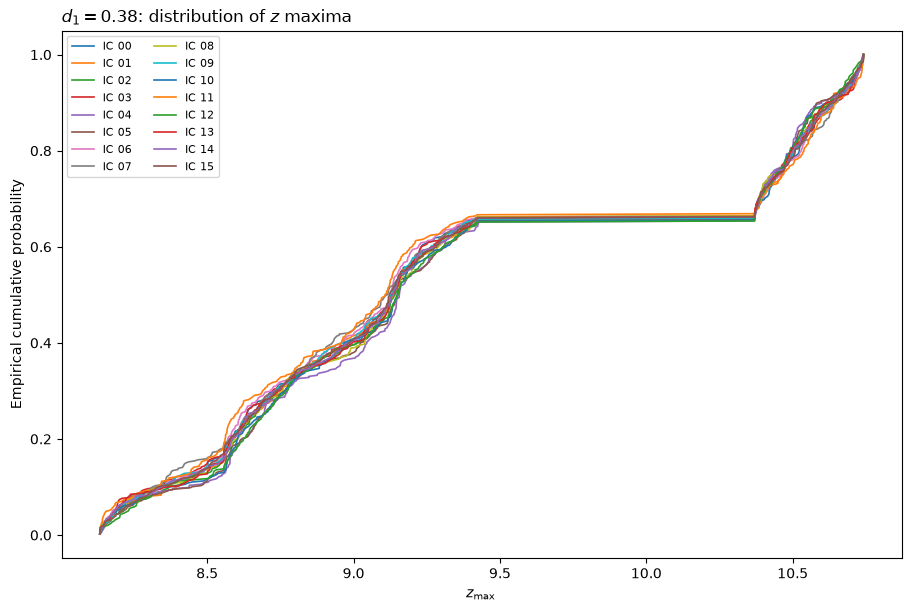

In [21]:
# Distribution of z maxima at d1 = 0.38

fig, ax = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True
)


for i in range(len(initial_states)):

    peaks = maxima_038[
        maxima_038[:, 0] == i,
        2
    ]

    peaks = np.sort(
        peaks
    )

    cumulative = np.arange(
        1,
        len(peaks) + 1
    ) / len(peaks)

    ax.plot(
        peaks,
        cumulative,
        linewidth=1.2,
        label=f"IC {i:02d}"
    )


ax.set_xlabel(
    r"$z_{\max}$"
)

ax.set_ylabel(
    "Empirical cumulative probability"
)

ax.set_title(
    r"$d_1 = 0.38$: distribution of $z$ maxima",
    loc="left"
)

ax.legend(
    ncol=2,
    fontsize=8
)


fig.savefig(
    "figures/hp_d1_038_maxima_ecdf.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_d1_038_maxima_ecdf.pdf",
    bbox_inches="tight"
)

plt.show()

In [22]:
# Compare the z-maxima distributions at d1 = 0.38

reference_peaks_038 = maxima_038[
    maxima_038[:, 0] == 0,
    2
]

reference_peaks_038 = np.sort(
    reference_peaks_038
)


ecdf_distance_038 = np.zeros(
    len(initial_states)
)


print(
    "IC   mean_zmax   std_zmax   "
    "ECDF_distance"
)


for i in range(len(initial_states)):

    peaks = maxima_038[
        maxima_038[:, 0] == i,
        2
    ]

    peaks = np.sort(
        peaks
    )


    # Common grid for both distributions
    values = np.sort(
        np.concatenate([
            reference_peaks_038,
            peaks
        ])
    )


    reference_ecdf = np.searchsorted(
        reference_peaks_038,
        values,
        side="right"
    ) / len(reference_peaks_038)

    current_ecdf = np.searchsorted(
        peaks,
        values,
        side="right"
    ) / len(peaks)


    ecdf_distance_038[i] = np.max(
        np.abs(
            reference_ecdf
            - current_ecdf
        )
    )


    print(
        f"{i:02d}   "
        f"{np.mean(peaks):.6f}   "
        f"{np.std(peaks):.6f}   "
        f"{ecdf_distance_038[i]:.6f}"
    )

IC   mean_zmax   std_zmax   ECDF_distance
00   9.396139   0.887050   0.000000
01   9.403850   0.880079   0.028174
02   9.411028   0.876563   0.030569
03   9.392516   0.889216   0.018921
04   9.426209   0.863833   0.063028
05   9.418889   0.864775   0.056034
06   9.385887   0.892025   0.031038
07   9.382014   0.894379   0.039112
08   9.399859   0.875595   0.027745
09   9.395476   0.886472   0.023128
10   9.416075   0.873191   0.047699
11   9.368510   0.901338   0.047258
12   9.418015   0.869937   0.049181
13   9.398494   0.879442   0.024664
14   9.397342   0.881414   0.022033
15   9.396448   0.882231   0.023290


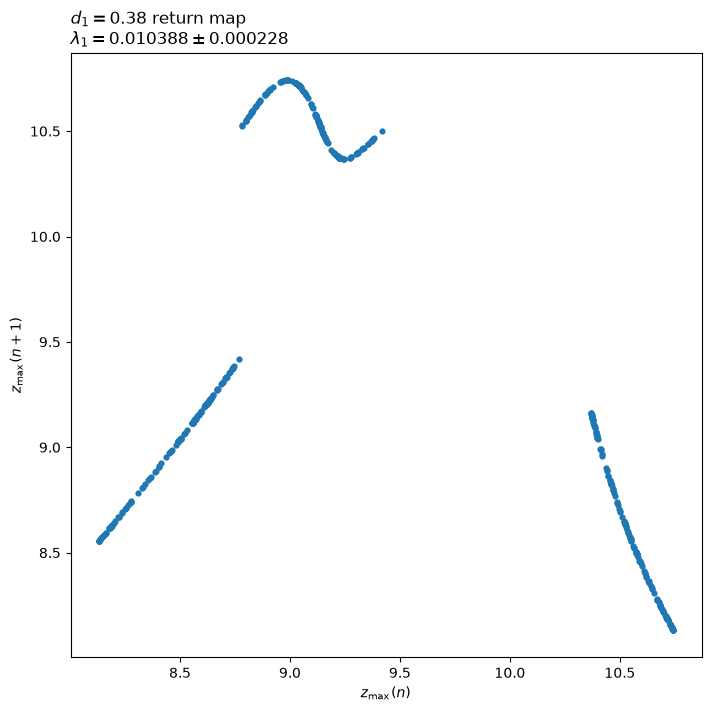

In [23]:
# Return map at d1 = 0.38

reference_maxima_038 = maxima_038[
    maxima_038[:, 0] == 0
]

reference_maxima_038 = reference_maxima_038[
    np.argsort(
        reference_maxima_038[:, 1]
    )
]

peaks_038 = reference_maxima_038[
    :,
    2
]


fig, ax = plt.subplots(
    figsize=(7, 7),
    constrained_layout=True
)


ax.scatter(
    peaks_038[:-1],
    peaks_038[1:],
    s=12
)


ax.set_xlabel(
    r"$z_{\max}(n)$"
)

ax.set_ylabel(
    r"$z_{\max}(n+1)$"
)

ax.set_title(
    (
        r"$d_1 = 0.38$ return map"
        "\n"
        rf"$\lambda_1 = {checks_038[0, 4]:.6f}"
        rf" \pm {checks_038[0, 5]:.6f}$"
    ),
    loc="left"
)


fig.savefig(
    "figures/hp_d1_038_return_map.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_d1_038_return_map.pdf",
    bbox_inches="tight"
)

plt.show()

In [24]:
# Time-step convergence check at d1 = 0.38

(
    block_exponents_dt_038,
    final_state_dt_038,
    mean_trace_dt_038
) = lyapunov_spectrum_blocks(
    parameters_038,
    reference_state,
    dt_half,
    transient_time,
    alignment_time,
    average_time,
    renormalization_time,
    block_time
)


(
    spectrum_dt_038,
    errors_dt_038,
    first_half_dt_038,
    second_half_dt_038,
    drift_dt_038,
    stationary_dt_038
) = spectrum_statistics(
    block_exponents_dt_038
)


spectrum_sum_dt_038 = np.sum(
    spectrum_dt_038
)

trace_difference_dt_038 = abs(
    spectrum_sum_dt_038
    - mean_trace_dt_038
)


print(
    "dt:",
    dt_half
)

print(
    "Spectrum:",
    spectrum_dt_038
)

print(
    "Errors:",
    errors_dt_038
)

print(
    "Drift:",
    drift_dt_038
)

print(
    "Stationary:",
    stationary_dt_038
)

print(
    "Trace difference:",
    trace_difference_dt_038
)

dt: 0.005
Spectrum: [ 1.06498467e-02 -4.32971308e-06 -4.65991416e-01]
Errors: [0.00021459 0.00013526 0.00080955]
Drift: [7.17991014e-05 1.57739349e-05 1.65714449e-04]
Stationary: [ True  True  True]
Trace difference: 3.79046349863188e-09


In [25]:
# Compare dt = 0.01 and dt = 0.005 at d1 = 0.38

spectrum_main_038 = np.array([
    checks_038[0, 4],
    checks_038[0, 6],
    checks_038[0, 8]
])

errors_main_038 = np.array([
    checks_038[0, 5],
    checks_038[0, 7],
    checks_038[0, 9]
])


difference_dt_038 = np.abs(
    spectrum_main_038
    - spectrum_dt_038
)

combined_error_038 = (
    errors_main_038
    + errors_dt_038
)

consistent_dt_038 = (
    difference_dt_038
    <= combined_error_038
)


print(
    "Exponent   dt=0.01      dt=0.005     "
    "difference    combined_error    consistent"
)


for i in range(3):

    print(
        f"lambda{i + 1}    "
        f"{spectrum_main_038[i]: .6f}    "
        f"{spectrum_dt_038[i]: .6f}    "
        f"{difference_dt_038[i]:.6f}      "
        f"{combined_error_038[i]:.6f}          "
        f"{consistent_dt_038[i]}"
    )

Exponent   dt=0.01      dt=0.005     difference    combined_error    consistent
lambda1     0.010388     0.010650    0.000262      0.000443          True
lambda2    -0.000000    -0.000004    0.000004      0.000292          True
lambda3    -0.465575    -0.465991    0.000417      0.001645          True


In [26]:
# Report stationarity flags at d1 = 0.38

error_columns = [5, 7, 9]
first_half_columns = [10, 11, 12]
second_half_columns = [13, 14, 15]
drift_columns = [16, 17, 18]
stationary_columns = [19, 20, 21]


print("Main integration: dt = 0.01")
print()


flagged_main_038 = []


for row in checks_038:

    ic_index = int(
        row[0]
    )

    for exponent_index in range(3):

        stationary_value = bool(
            row[
                stationary_columns[
                    exponent_index
                ]
            ]
        )

        if not stationary_value:

            error = row[
                error_columns[
                    exponent_index
                ]
            ]

            drift = row[
                drift_columns[
                    exponent_index
                ]
            ]

            ratio = (
                drift / error
                if error > 0.0
                else np.inf
            )


            flagged_main_038.append([
                ic_index,
                exponent_index + 1,
                row[
                    first_half_columns[
                        exponent_index
                    ]
                ],
                row[
                    second_half_columns[
                        exponent_index
                    ]
                ],
                drift,
                error,
                ratio
            ])


            print(
                f"IC {ic_index:02d}   "
                f"lambda{exponent_index + 1}   "
                f"first = "
                f"{row[first_half_columns[exponent_index]]:.6f}   "
                f"second = "
                f"{row[second_half_columns[exponent_index]]:.6f}   "
                f"drift = {drift:.6f}   "
                f"error = {error:.6f}   "
                f"drift/error = {ratio:.3f}"
            )


if len(flagged_main_038) == 0:

    print(
        "No stationarity flags."
    )


print()
print("Convergence integration: dt = 0.005")
print()


flagged_half_038 = []


for exponent_index in range(3):

    if not stationary_dt_038[
        exponent_index
    ]:

        error = errors_dt_038[
            exponent_index
        ]

        drift = drift_dt_038[
            exponent_index
        ]

        ratio = (
            drift / error
            if error > 0.0
            else np.inf
        )


        flagged_half_038.append([
            exponent_index + 1,
            first_half_dt_038[
                exponent_index
            ],
            second_half_dt_038[
                exponent_index
            ],
            drift,
            error,
            ratio
        ])


        print(
            f"lambda{exponent_index + 1}   "
            f"first = "
            f"{first_half_dt_038[exponent_index]:.6f}   "
            f"second = "
            f"{second_half_dt_038[exponent_index]:.6f}   "
            f"drift = {drift:.6f}   "
            f"error = {error:.6f}   "
            f"drift/error = {ratio:.3f}"
        )


if len(flagged_half_038) == 0:

    print(
        "No stationarity flags."
    )

Main integration: dt = 0.01

IC 01   lambda3   first = -0.465417   second = -0.466447   drift = 0.001029   error = 0.000985   drift/error = 1.045
IC 05   lambda3   first = -0.466932   second = -0.465844   drift = 0.001088   error = 0.000898   drift/error = 1.212
IC 11   lambda1   first = 0.010476   second = 0.010693   drift = 0.000217   error = 0.000198   drift/error = 1.095
IC 13   lambda1   first = 0.010679   second = 0.010425   drift = 0.000254   error = 0.000196   drift/error = 1.293

Convergence integration: dt = 0.005

No stationarity flags.


In [27]:
# Save all results for d1 = 0.38


# Add the ECDF distance to the main summary

checks_038_save = np.column_stack([
    checks_038,
    ecdf_distance_038
])


checks_header_038 = """Hastings-Powell working-point checks at d1 = 0.38

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.38
d2 = 0.01

Main integration:
dt = 0.01
transient_time = 20000
alignment_time = 5000
average_time = 200000
renormalization_time = 1
block_time = 2500

z-maxima:
record_time = 20000
max_peaks = 500

Initial conditions:
reference = [1.0, 1.0, 1.0]
15 random initial conditions
random interval = [0.1, 2.0]
random seed = 12345

Errors:
largest half-width among approximate 95% Student intervals
obtained with block groupings of 1, 2 and 4

Stationarity:
first-half and second-half Lyapunov means are compared
component by component
stationary = 1 when drift <= reported error

ECDF distance:
maximum absolute difference from the empirical distribution
of z maxima for the reference initial condition

columns:
IC,x0,y0,z0,
lambda1,error1,lambda2,error2,lambda3,error3,
first_half1,first_half2,first_half3,
second_half1,second_half2,second_half3,
drift1,drift2,drift3,
stationary1,stationary2,stationary3,
spectrum_sum,mean_trace,trace_difference,
distinct_maxima,mean_zmax,std_zmax,
final_x,final_y,final_z,
ecdf_distance
"""


np.savetxt(
    "data/hp_d1_038_checks.csv",
    checks_038_save,
    delimiter=",",
    header=checks_header_038,
    comments="# ",
    fmt="%.16e"
)


# Main dt = 0.01 blocks

main_blocks_038 = np.column_stack([
    np.full(
        len(blocks_038),
        dt_main
    ),
    blocks_038
])


# Reference-condition blocks for dt = 0.005

half_blocks_038 = np.column_stack([
    np.full(
        len(block_exponents_dt_038),
        dt_half
    ),
    np.zeros(
        len(block_exponents_dt_038)
    ),
    np.arange(
        1,
        len(block_exponents_dt_038) + 1
    ),
    block_exponents_dt_038
])


all_blocks_038 = np.vstack([
    main_blocks_038,
    half_blocks_038
])


blocks_header_038 = """Lyapunov blocks at d1 = 0.38

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.38
d2 = 0.01

Integration:
transient_time = 20000
alignment_time = 5000
average_time = 200000
renormalization_time = 1
block_time = 2500

dt = 0.01:
16 initial conditions

dt = 0.005:
reference initial condition only
IC = 0
reference = [1.0, 1.0, 1.0]

columns:
dt,IC,block,lambda1_block,lambda2_block,lambda3_block
"""


np.savetxt(
    "data/hp_d1_038_blocks.csv",
    all_blocks_038,
    delimiter=",",
    header=blocks_header_038,
    comments="# ",
    fmt="%.16e"
)


# Save z maxima in temporal order

maxima_header_038 = """Successive maxima of z at d1 = 0.38

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.38
d2 = 0.01

dt = 0.01
transient_time = 20000
record_time = 20000
max_peaks = 500

Initial conditions:
reference = [1.0, 1.0, 1.0]
15 random initial conditions
random interval = [0.1, 2.0]
random seed = 12345

columns:
IC,peak_index,z_max
"""


np.savetxt(
    "data/hp_d1_038_maxima.csv",
    maxima_038,
    delimiter=",",
    header=maxima_header_038,
    comments="# ",
    fmt="%.16e"
)


# Add stationarity details to the dt comparison

main_first_half_038 = np.array([
    checks_038[0, 10],
    checks_038[0, 11],
    checks_038[0, 12]
])

main_second_half_038 = np.array([
    checks_038[0, 13],
    checks_038[0, 14],
    checks_038[0, 15]
])

main_drift_038 = np.array([
    checks_038[0, 16],
    checks_038[0, 17],
    checks_038[0, 18]
])

main_stationary_038 = np.array([
    checks_038[0, 19],
    checks_038[0, 20],
    checks_038[0, 21]
])


dt_convergence_038 = np.column_stack([
    np.arange(1, 4),

    spectrum_main_038,
    errors_main_038,
    main_first_half_038,
    main_second_half_038,
    main_drift_038,
    main_stationary_038,

    spectrum_dt_038,
    errors_dt_038,
    first_half_dt_038,
    second_half_dt_038,
    drift_dt_038,
    stationary_dt_038.astype(float),

    difference_dt_038,
    combined_error_038,
    consistent_dt_038.astype(float)
])


dt_header_038 = f"""Time-step convergence check at d1 = 0.38

Parameters:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.38
d2 = 0.01

Initial condition:
[1.0, 1.0, 1.0]

Integration:
transient_time = 20000
alignment_time = 5000
average_time = 200000
renormalization_time = 1
block_time = 2500

main_dt = 0.01
half_dt = 0.005

main_trace_difference = {checks_038[0, 24]:.16e}
half_trace_difference = {trace_difference_dt_038:.16e}

Stationarity criterion:
drift <= reported error

Time-step consistency criterion:
absolute difference <= error_dt_0.01 + error_dt_0.005

columns:
exponent,
lambda_dt_0.01,error_dt_0.01,
first_half_dt_0.01,second_half_dt_0.01,
drift_dt_0.01,stationary_dt_0.01,
lambda_dt_0.005,error_dt_0.005,
first_half_dt_0.005,second_half_dt_0.005,
drift_dt_0.005,stationary_dt_0.005,
absolute_difference,combined_error,consistent
"""


np.savetxt(
    "data/hp_d1_038_dt_convergence.csv",
    dt_convergence_038,
    delimiter=",",
    header=dt_header_038,
    comments="# ",
    fmt="%.16e"
)


print(
    "Saved: data/hp_d1_038_checks.csv"
)

print(
    "Saved: data/hp_d1_038_blocks.csv"
)

print(
    "Saved: data/hp_d1_038_maxima.csv"
)

print(
    "Saved: data/hp_d1_038_dt_convergence.csv"
)

Saved: data/hp_d1_038_checks.csv
Saved: data/hp_d1_038_blocks.csv
Saved: data/hp_d1_038_maxima.csv
Saved: data/hp_d1_038_dt_convergence.csv
